# Tech Layoffs & Hiring Trends — EDA

This notebook performs an end-to-end exploratory data analysis of the uploaded **Tech Layoffs & Hiring Trends** dataset.

### EDA flow
1. Load and inspect the dataset
2. Data quality and missing-value analysis
3. Descriptive statistics
4. Univariate analysis
5. Categorical analysis
6. Correlation analysis
7. Time-based analysis where applicable
8. Outlier analysis
9. Key insights and conclusions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

file_path = '/content/tech_layoffs_hiring_trends_elite_v2-selected-columns.csv'
df = pd.read_csv(file_path)

print(f'Dataset shape: {df.shape}')
display(df.head())

Dataset shape: (12000, 10)


,record_id,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs
0,T0,Microsoft,AI,Singapore,Enterprise,Mar,2026,860,1.8,AI Automation
1,T1,Palantir,AI,Canada,Big Tech,Feb,2024,955,1.8,Cost Cutting
2,T2,Anthropic,Cybersecurity,USA,Mid-size,Apr,2025,18912,9.5,Overhiring Correction
3,T3,Spotify,Gaming,USA,Mid-size,Jun,2025,18159,9.1,Cost Cutting
4,T4,Uber,Gaming,UK,Startup,Feb,2025,815,3.3,Market Slowdown


## 1. Dataset Overview

In [2]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

overview = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Non-Null': df.notna().sum().values,
    'Missing': df.isna().sum().values,
    'Missing %': (df.isna().mean().values * 100).round(2),
    'Unique Values': df.nunique(dropna=True).values
})
display(overview)

print('\nDuplicate rows:', df.duplicated().sum())


Rows: 12000
Columns: 10


,Column,Data Type,Non-Null,Missing,Missing %,Unique Values
0,record_id,object,12000,0,0.0,12000
1,company_name,object,12000,0,0.0,20
2,industry,object,12000,0,0.0,7
3,country,object,12000,0,0.0,6
4,company_size,object,12000,0,0.0,4
5,month,object,12000,0,0.0,12
6,year,int64,12000,0,0.0,3
7,layoffs_count,int64,12000,0,0.0,7081
8,layoff_percentage,float64,12000,0,0.0,401
9,reason_for_layoffs,object,12000,0,0.0,5



Duplicate rows: 0


## 2. Data Quality Checks

In [3]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing):
    display(missing.to_frame('Missing Values'))
    plt.figure(figsize=(10, 5))
    missing.plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

# Duplicate rows
print('Duplicate rows:', df.duplicated().sum())


No missing values found.
Duplicate rows: 0


## 3. Descriptive Statistics

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print('Numeric columns:', numeric_cols)
print('\nCategorical / non-numeric columns:', categorical_cols)

if numeric_cols:
    display(df[numeric_cols].describe().T)

if categorical_cols:
    display(df[categorical_cols].describe().T)


Numeric columns: ['year', 'layoffs_count', 'layoff_percentage']

Categorical / non-numeric columns: ['record_id', 'company_name', 'industry', 'country', 'company_size', 'month', 'reason_for_layoffs']


,count,mean,std,min,25%,50%,75%,max
year,12000.0,2024.998750,0.817703,2024.0,2024.0,2025.0,2026.0,2026.0
layoffs_count,12000.0,5009.572083,5159.360491,0.0,1369.5,2733.0,6490.0,19999.0
layoff_percentage,12000.0,12.780125,10.212612,0.0,5.1,9.4,17.3,40.0


,count,unique,top,freq
record_id,12000,12000,T11983,1
company_name,12000,20,Databricks,644
industry,12000,7,Social Media,1742
country,12000,6,Singapore,2043
company_size,12000,4,Big Tech,3066
month,12000,12,Feb,1053
reason_for_layoffs,12000,5,AI Automation,2435


## 4. Numerical Feature Distributions

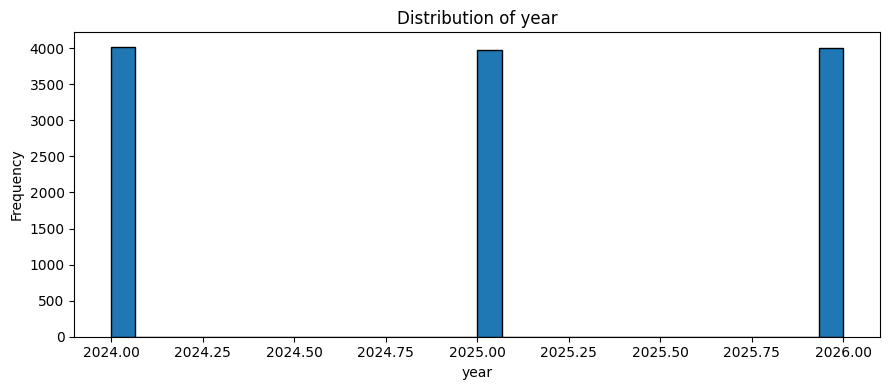

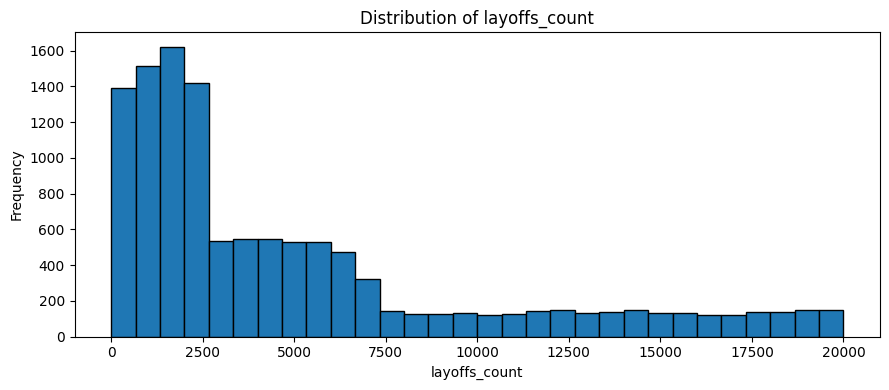

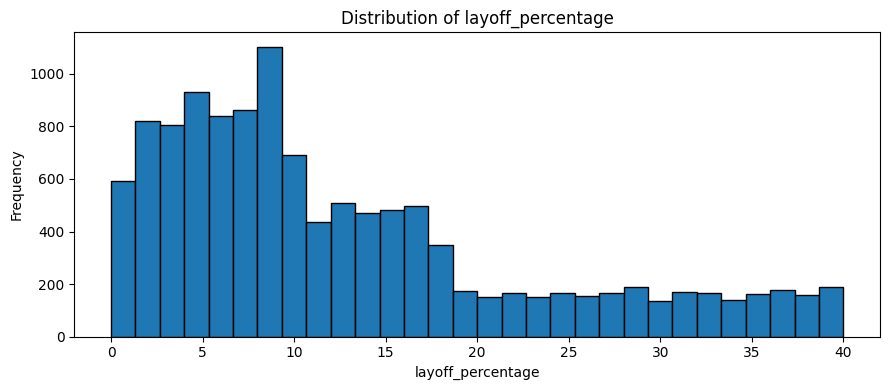

In [5]:
for col in numeric_cols:
    plt.figure(figsize=(9, 4))
    plt.hist(df[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


## 5. Categorical Feature Analysis


Top values for: record_id


,Count
record_id,
T11983,1
T11982,1
T11981,1
T11980,1
T11979,1
T11978,1
T11977,1
T11976,1
T11975,1


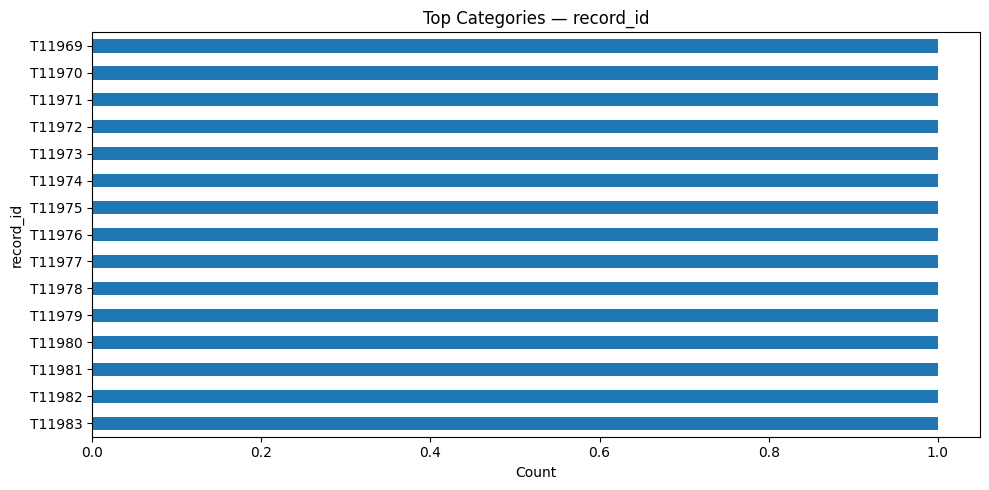


Top values for: company_name


,Count
company_name,
Databricks,644
OpenAI,640
Spotify,638
Google,632
NVIDIA,616
Salesforce,615
Apple,615
Meta,611
Oracle,606


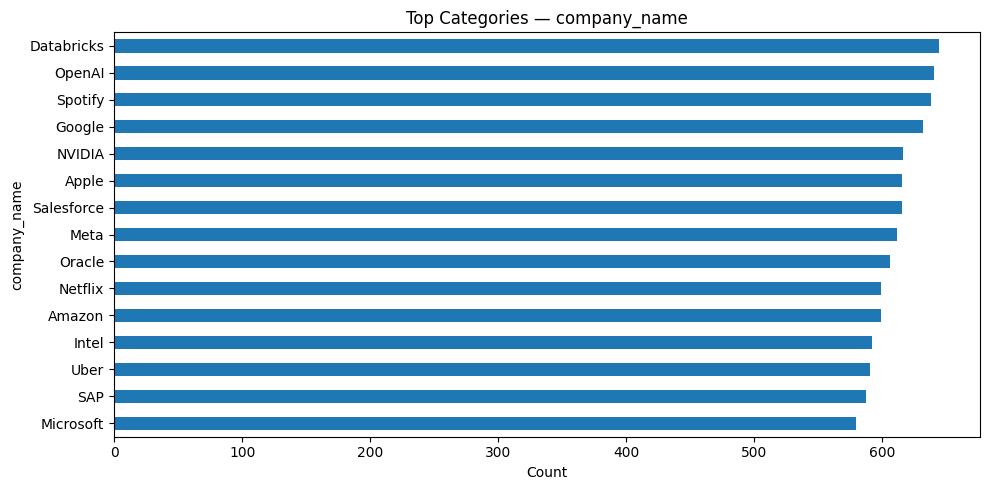


Top values for: industry


,Count
industry,
Social Media,1742
E-Commerce,1732
Cloud,1719
Cybersecurity,1714
Gaming,1712
AI,1692
FinTech,1689


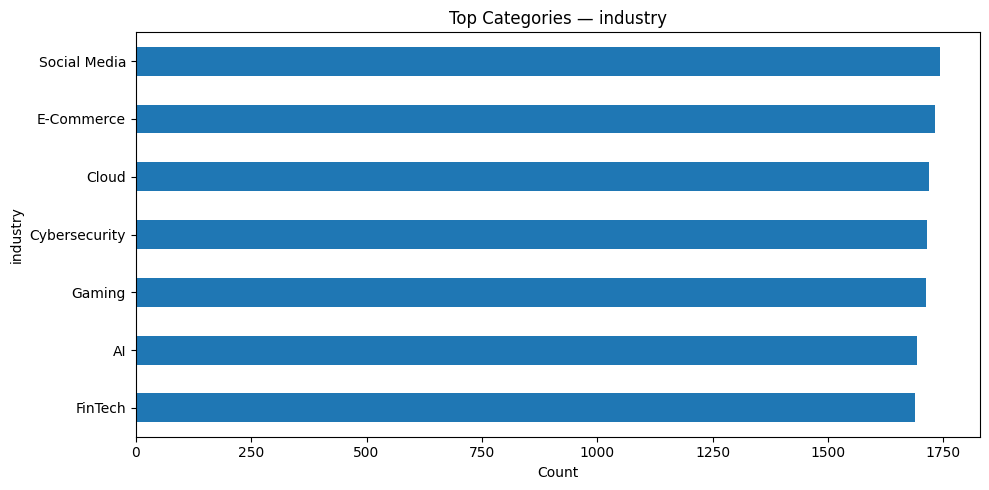


Top values for: country


,Count
country,
Singapore,2043
UK,2037
USA,2008
India,1976
Canada,1968
Germany,1968


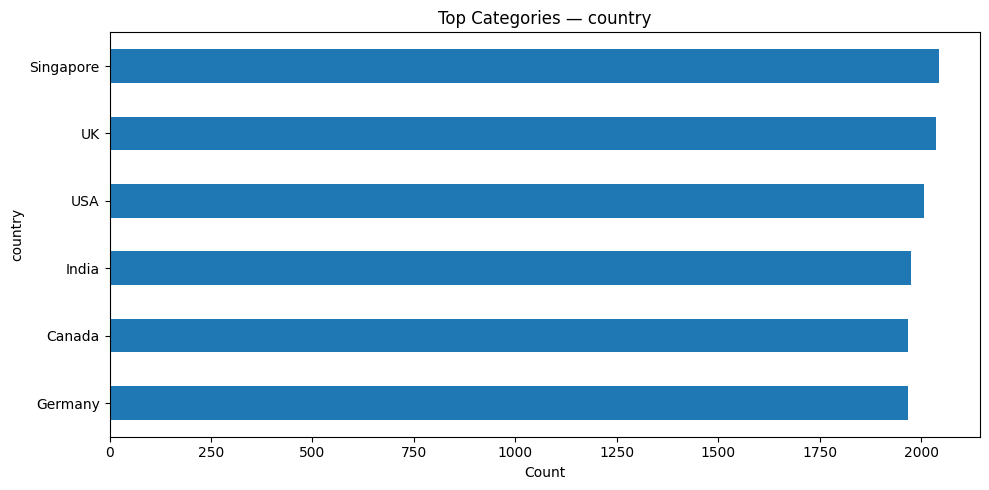


Top values for: company_size


,Count
company_size,
Big Tech,3066
Enterprise,2992
Mid-size,2976
Startup,2966


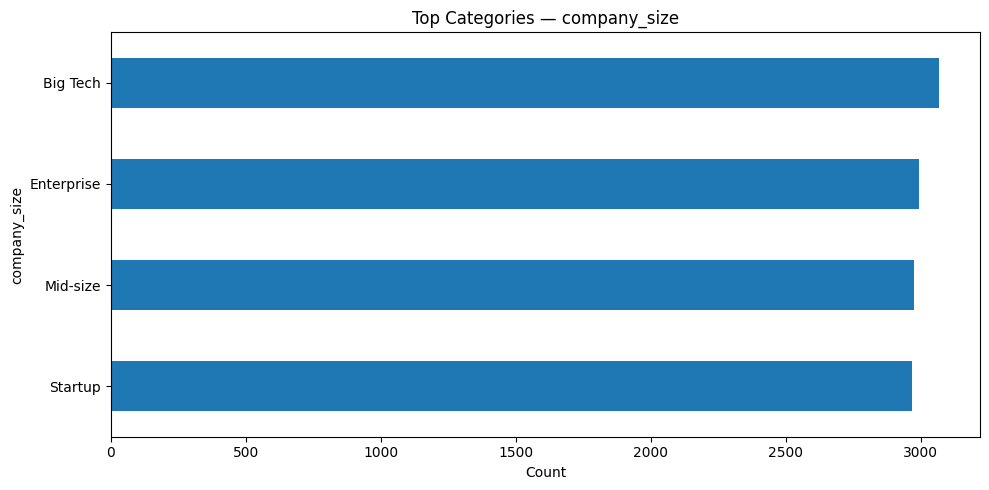


Top values for: month


,Count
month,
Feb,1053
Apr,1030
Sep,1023
Jul,1011
Oct,1008
Mar,1001
Jan,998
Aug,997
Dec,994


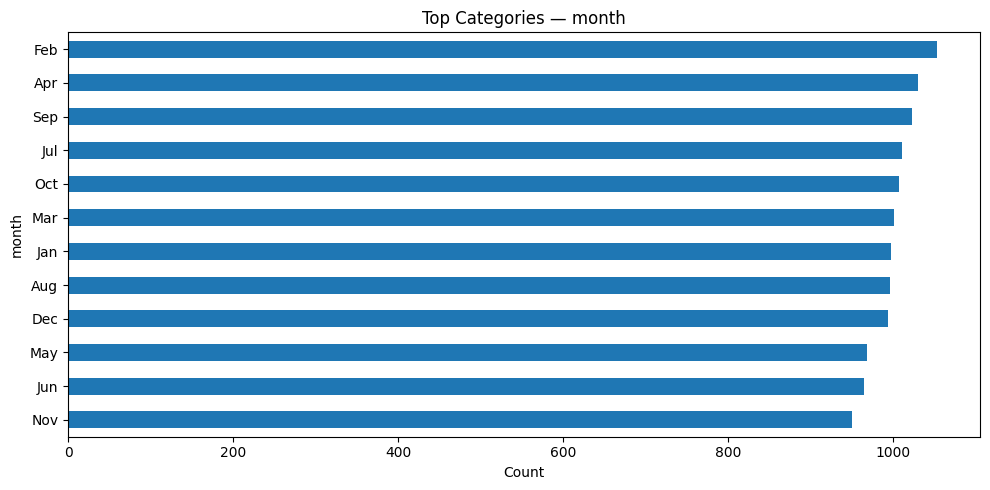


Top values for: reason_for_layoffs


,Count
reason_for_layoffs,
AI Automation,2435
Overhiring Correction,2433
Restructuring,2401
Cost Cutting,2397
Market Slowdown,2334


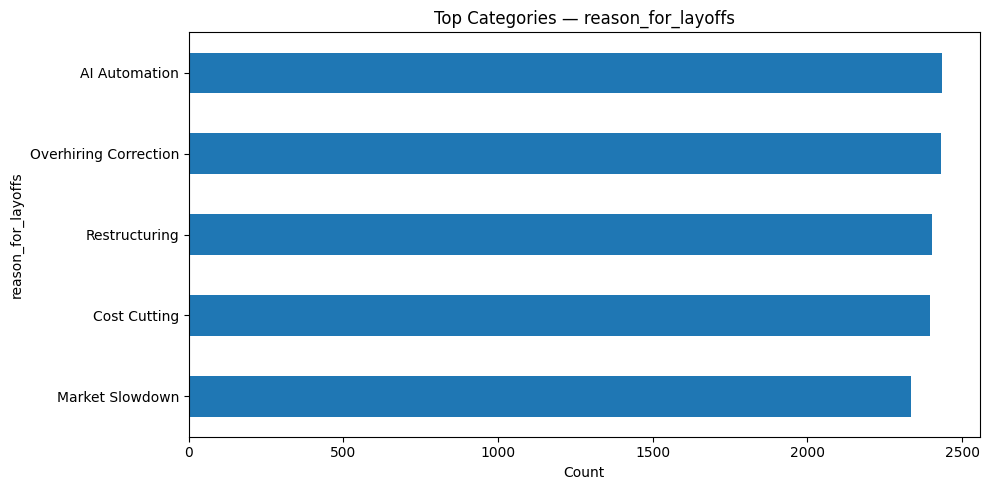

In [6]:
for col in categorical_cols:
    counts = df[col].value_counts(dropna=False).head(15)
    print(f'\nTop values for: {col}')
    display(counts.to_frame('Count'))

    if len(counts) > 1:
        plt.figure(figsize=(10, 5))
        counts.sort_values().plot(kind='barh')
        plt.title(f'Top Categories — {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


## 6. Correlation Analysis

,year,layoffs_count,layoff_percentage
year,1.000000,-0.003689,-0.004198
layoffs_count,-0.003689,1.000000,0.598016
layoff_percentage,-0.004198,0.598016,1.000000


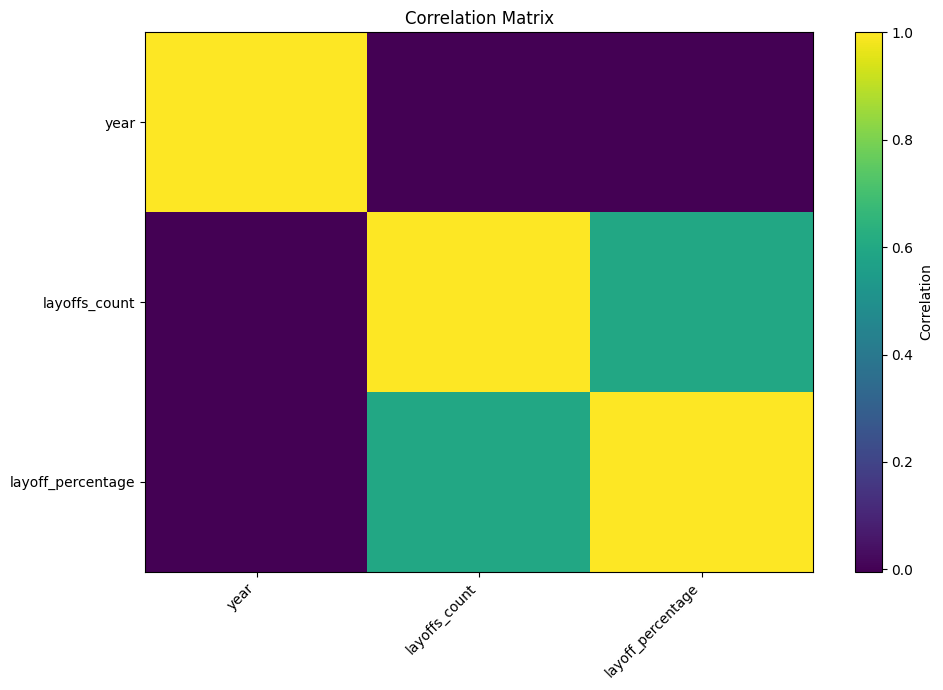

In [7]:
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)
    display(corr)

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(corr, aspect='auto')
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr.columns)
    fig.colorbar(im, ax=ax, label='Correlation')
    ax.set_title('Correlation Matrix')
    plt.tight_layout()
    plt.show()
else:
    print('At least two numeric columns are required for correlation analysis.')


## 7. Automatic Date / Time Analysis

Potential date/time columns: ['month', 'year']


/tmp/ipykernel_885/1366446506.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col], errors='coerce')


,Records
_parsed_date,
1970,12000


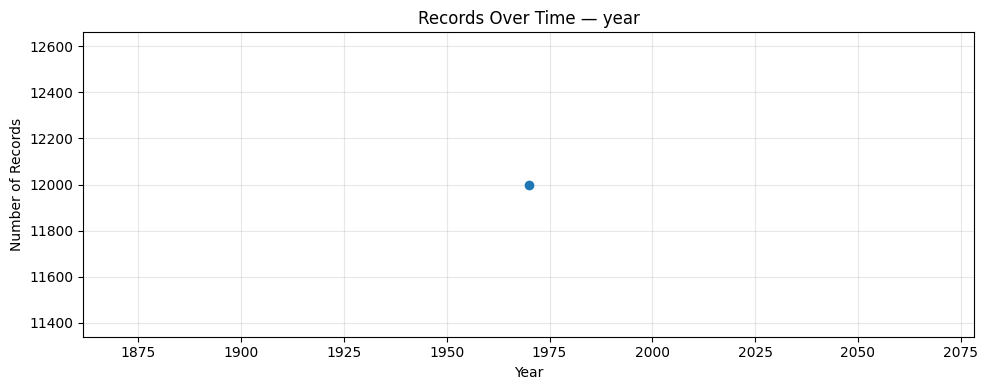

In [8]:
date_candidates = []
for col in df.columns:
    name = col.lower()
    if any(k in name for k in ['date', 'year', 'month', 'time']):
        date_candidates.append(col)

print('Potential date/time columns:', date_candidates)

for col in date_candidates:
    parsed = pd.to_datetime(df[col], errors='coerce')
    if parsed.notna().mean() >= 0.5:
        temp = df.copy()
        temp['_parsed_date'] = parsed
        yearly = temp.dropna(subset=['_parsed_date']).groupby(temp['_parsed_date'].dt.year).size()
        if len(yearly):
            display(yearly.to_frame('Records'))
            plt.figure(figsize=(10, 4))
            yearly.plot(kind='line', marker='o')
            plt.title(f'Records Over Time — {col}')
            plt.xlabel('Year')
            plt.ylabel('Number of Records')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


## 8. Outlier Analysis

In [9]:
outlier_summary = []

for col in numeric_cols:
    s = df[col].dropna()
    if len(s) == 0:
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((s < lower) | (s > upper)).sum()
    outlier_summary.append([col, q1, q3, lower, upper, int(count)])

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary, columns=['Column','Q1','Q3','Lower Bound','Upper Bound','Outliers'])
    display(outlier_df)


,Column,Q1,Q3,Lower Bound,Upper Bound,Outliers
0,year,2024.0,2026.0,2021.00,2029.00,0
1,layoffs_count,1369.5,6490.0,-6311.25,14170.75,1194
2,layoff_percentage,5.1,17.3,-13.20,35.60,564


## 9. Key Business Questions

Use the following questions to turn the EDA into a data-analytics story:

- Which companies, industries, or locations appear most frequently?
- Which periods show the highest concentration of layoffs or hiring activity?
- What are the most common layoff reasons or hiring patterns, if those fields exist?
- How are layoffs distributed across company sizes or industries?
- Are there relationships between workforce size, layoffs, funding, revenue, or other numeric measures?
- Which categories contain unusually high or low values?
- What trends could be useful for HR, recruiters, candidates, or business decision-makers?


## 10. Automatic Dataset Summary

In [10]:
print('===== EDA SUMMARY =====')
print(f'Total records: {len(df):,}')
print(f'Total columns: {df.shape[1]}')
print(f'Duplicate rows: {df.duplicated().sum():,}')
print(f'Total missing cells: {df.isna().sum().sum():,}')

if numeric_cols:
    print('\nNumeric columns:')
    for col in numeric_cols:
        print(f' - {col}: mean={df[col].mean():.2f}, median={df[col].median():.2f}')

if categorical_cols:
    print('\nCategorical columns:')
    for col in categorical_cols:
        print(f' - {col}: {df[col].nunique(dropna=True)} unique values')

print('\nEDA completed successfully.')


===== EDA SUMMARY =====
Total records: 12,000
Total columns: 10
Duplicate rows: 0
Total missing cells: 0

Numeric columns:
 - year: mean=2025.00, median=2025.00
 - layoffs_count: mean=5009.57, median=2733.00
 - layoff_percentage: mean=12.78, median=9.40

Categorical columns:
 - record_id: 12000 unique values
 - company_name: 20 unique values
 - industry: 7 unique values
 - country: 6 unique values
 - company_size: 4 unique values
 - month: 12 unique values
 - reason_for_layoffs: 5 unique values

EDA completed successfully.
